In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install pandas pillow

In [2]:
!pip install pandas
!pip install opencv-python

In [3]:
!pip install tensorflow==2.12.0
!pip install keras

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 3.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 48.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 7.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 5.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 21.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: wrapt
    F

In [4]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import os
from tensorflow import keras
import glob as gb
import pandas as pd
from tensorflow.keras.preprocessing import image_dataset_from_directory
# Import RandomFlip and RandomRotation from the preprocessing module
from tensorflow.keras.layers.experimental.preprocessing import RandomFlip, RandomRotation
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPool2D, LeakyReLU


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

IMG_SIZE = (299, 299) # resolution
directory = "/kaggle/input/wheat-dataset"
BATCH_SIZE = 128

train_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             validation_split=0.1,
                                             subset='training',
                                             color_mode='rgb',
                                             seed=42)

validation_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             validation_split=0.1,
                                             subset='validation',
                                             color_mode='rgb',
                                             seed=42)

Found 3791 files belonging to 3 classes.
Using 3412 files for training.
Found 3791 files belonging to 3 classes.
Using 379 files for validation.


In [6]:
class_names = train_dataset.class_names
class_names

['Wheat___Brown_Rust', 'Wheat___Healthy', 'Wheat___Yellow_Rust']

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


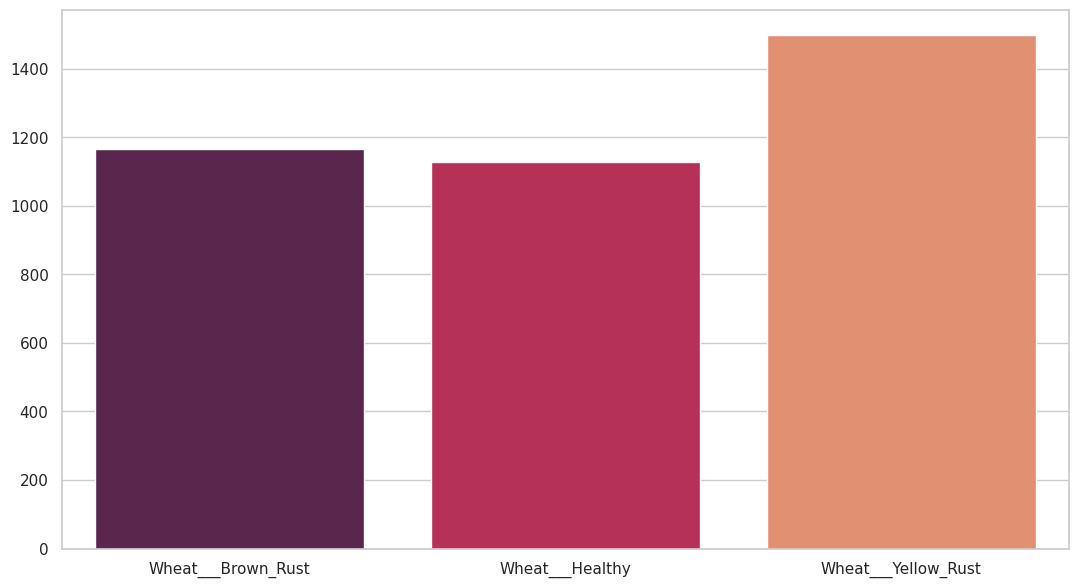

In [7]:
sns.set_theme(style="whitegrid")
Data_imbalance = []
for folder in os.listdir(directory):
    files = gb.glob(pathname=str(directory + "/" + folder +"/*.*"))
    Data_imbalance.append(len(files))
plt.figure(figsize=(13,7))
sns.barplot(x=['Wheat___Brown_Rust', 'Wheat___Healthy', 'Wheat___Yellow_Rust'], y=Data_imbalance, palette="rocket")
plt.show()

In [8]:
total = 0
for i in range(0,len(Data_imbalance)) :
    total +=Data_imbalance[i]

weight_for_0 = (1 / Data_imbalance[0]) * (total / 4.0)
weight_for_1 = (1 / Data_imbalance[1]) * (total / 4.0)
weight_for_2 = (1 / Data_imbalance[2]) * (total / 4.0)

class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2}

print('Weight for class 0: {:.2f}'.format(weight_for_0))
print('Weight for class 1: {:.2f}'.format(weight_for_1))
print('Weight for class 2: {:.2f}'.format(weight_for_2))

Weight for class 0: 0.81
Weight for class 1: 0.84
Weight for class 2: 0.63


In [9]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
  tf.keras.layers.RandomHeight(0.2),
  tf.keras.layers.RandomWidth(0.2),
])

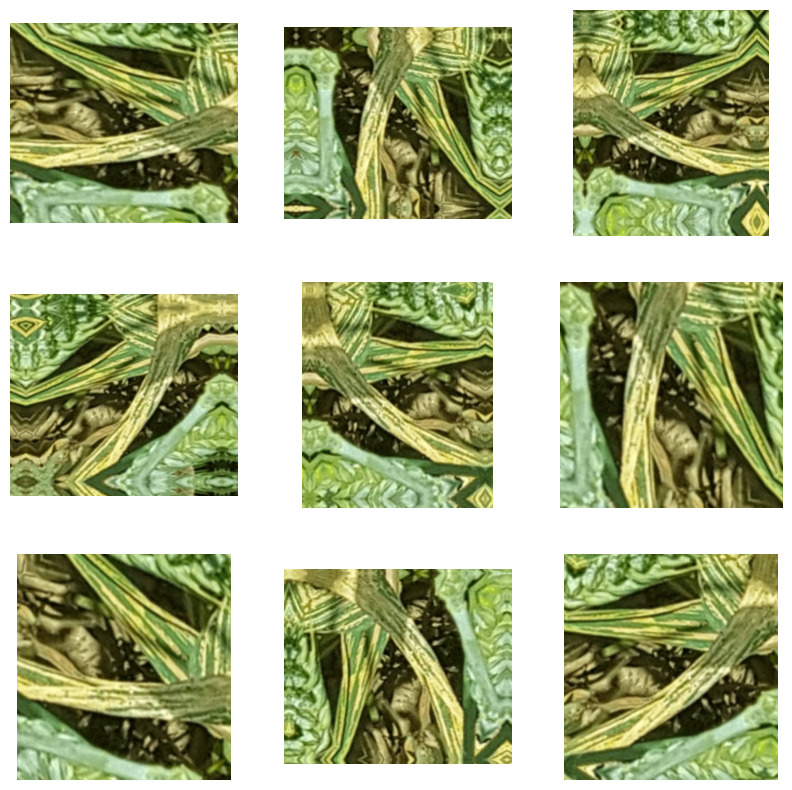

In [10]:
for image, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255)
        plt.axis('off')

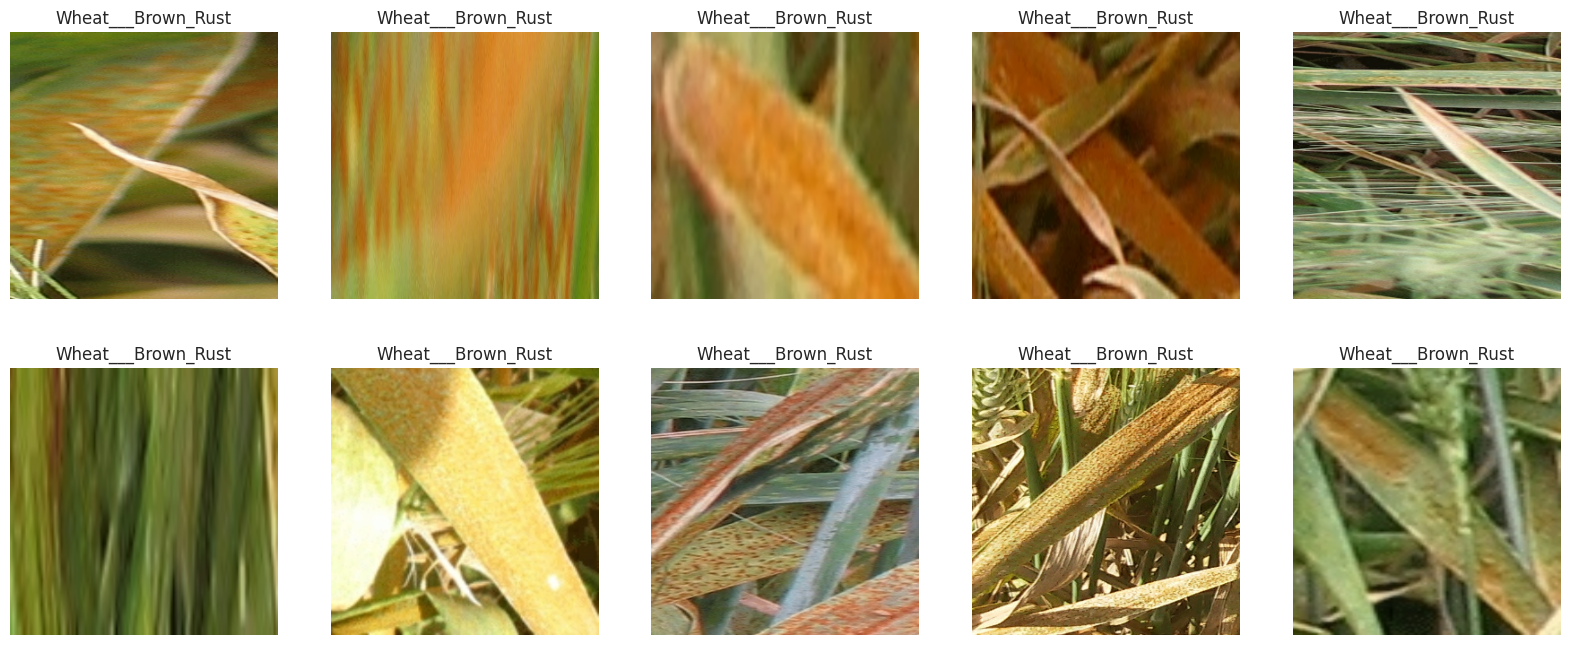

In [11]:
plt.figure(figsize=(20,8))
Wheat___Brown_Rust = []
Wheat___Yellow_Rust = []

# Iterate through more batches to collect more samples
for images , labels in train_dataset.take(10): # Increased from take(1) to take(10)
    # Iterate through the actual number of labels in the batch
    for i in range(labels.shape[0]):
        if class_names[labels[i]] == "Wheat___Brown_Rust":
            Wheat___Brown_Rust.append(images[i].numpy().astype("uint8"))
        if  class_names[labels[i]] == "Wheat___Yellow_Rust":
            Wheat___Yellow_Rust.append(images[i].numpy().astype("uint8"))

# Display only the available images, up to 10
for i in range(min(10, len(Wheat___Brown_Rust))): # Changed to display up to 10 or the available images
    plt.subplot(2,5,i+1)
    plt.imshow(Wheat___Brown_Rust[i])
    plt.axis("off")
    plt.title("Wheat___Brown_Rust")

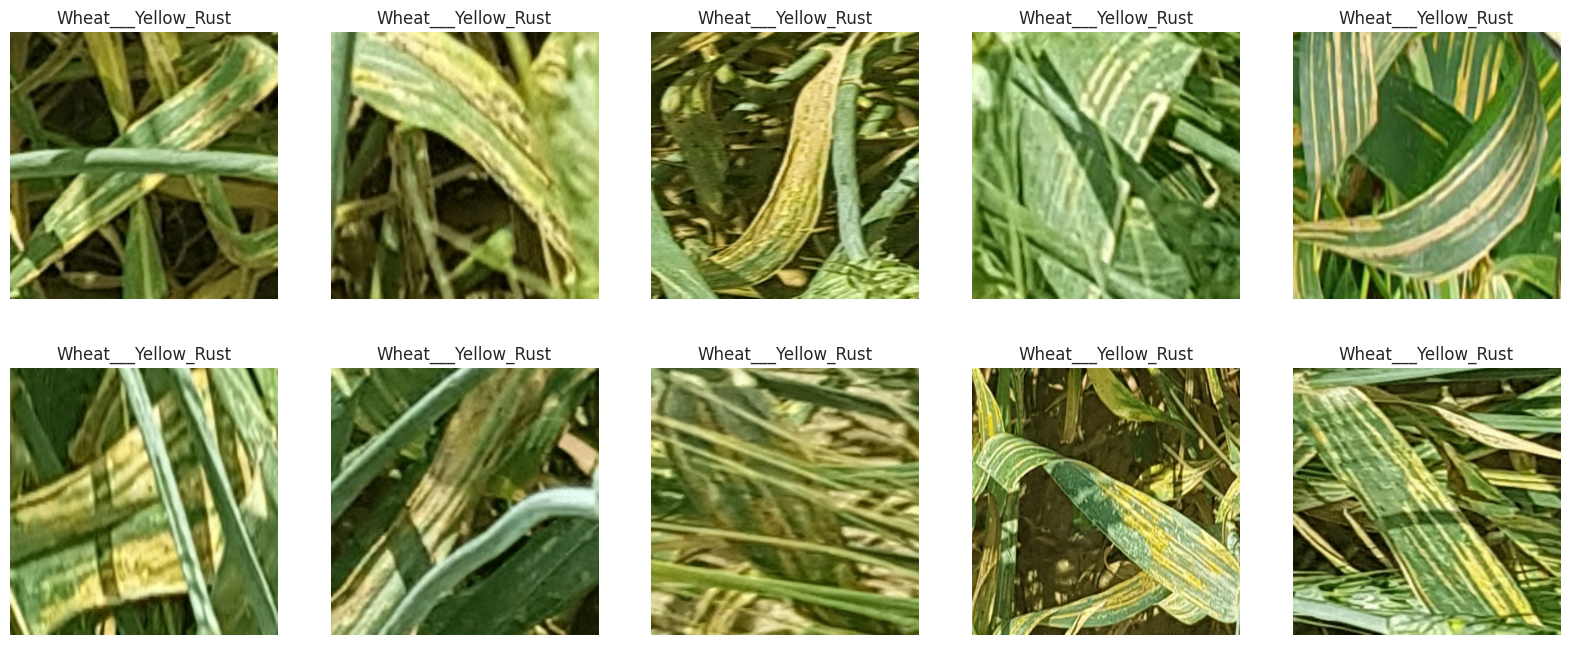

In [12]:
plt.figure(figsize=(20,8))
for i in range(min(10, len(Wheat___Yellow_Rust))): # Changed to display up to 10 or the available images
    plt.subplot(2,5,i+1)
    plt.imshow(Wheat___Yellow_Rust[i])
    plt.axis("off")
    plt.title("Wheat___Yellow_Rust")

In [13]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

In [14]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras import layers, models, optimizers

# Load VGG19 base model without top layers
base_model = VGG19(include_top=False,
                   input_shape=(299, 299, 3),
                   weights='imagenet')
base_model.trainable = False  # Freeze base layers

# Define the full model
model = models.Sequential([
    data_augmentation,  # Your defined augmentation layer
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')  # 3 classes for potato
])

# Compile the model
model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

80134624/80134624 [==============================] - 0s 0us/step


In [15]:
# Train the model
history = model.fit(train_dataset,
                    validation_data=validation_dataset,
                    epochs=10,
                    class_weight=class_weight)  # For data imbalance handling

# Evaluate the model on the validation dataset
test_loss, test_accuracy = model.evaluate(validation_dataset)

print(f"\n✅ Testing Accuracy: {test_accuracy * 100:.2f}%")
print(f"🧪 Testing Loss: {test_loss:.4f}")

Epoch 1/10
27/27 [==============================] - 1236s 46s/step - loss: 2.2828 - accuracy: 0.4130 - val_loss: 1.2576 - val_accuracy: 0.5488
Epoch 2/10
27/27 [==============================] - 1190s 44s/step - loss: 1.3558 - accuracy: 0.5372 - val_loss: 0.6115 - val_accuracy: 0.7652
Epoch 3/10
27/27 [==============================] - 1146s 42s/step - loss: 0.9756 - accuracy: 0.6336 - val_loss: 0.4477 - val_accuracy: 0.8259
Epoch 4/10
27/27 [==============================] - 1249s 46s/step - loss: 0.7233 - accuracy: 0.6946 - val_loss: 0.3438 - val_accuracy: 0.8760
Epoch 5/10
27/27 [==============================] - 1231s 46s/step - loss: 0.5991 - accuracy: 0.7403 - val_loss: 0.2860 - val_accuracy: 0.8945
Epoch 6/10
27/27 [==============================] - 1235s 46s/step - loss: 0.4735 - accuracy: 0.7934 - val_loss: 0.2456 - val_accuracy: 0.9103
Epoch 7/10
27/27 [==============================] - 1238s 45s/step - loss: 0.4467 - accuracy: 0.7869 - val_loss: 0.2305 - val_accuracy: 0.9156

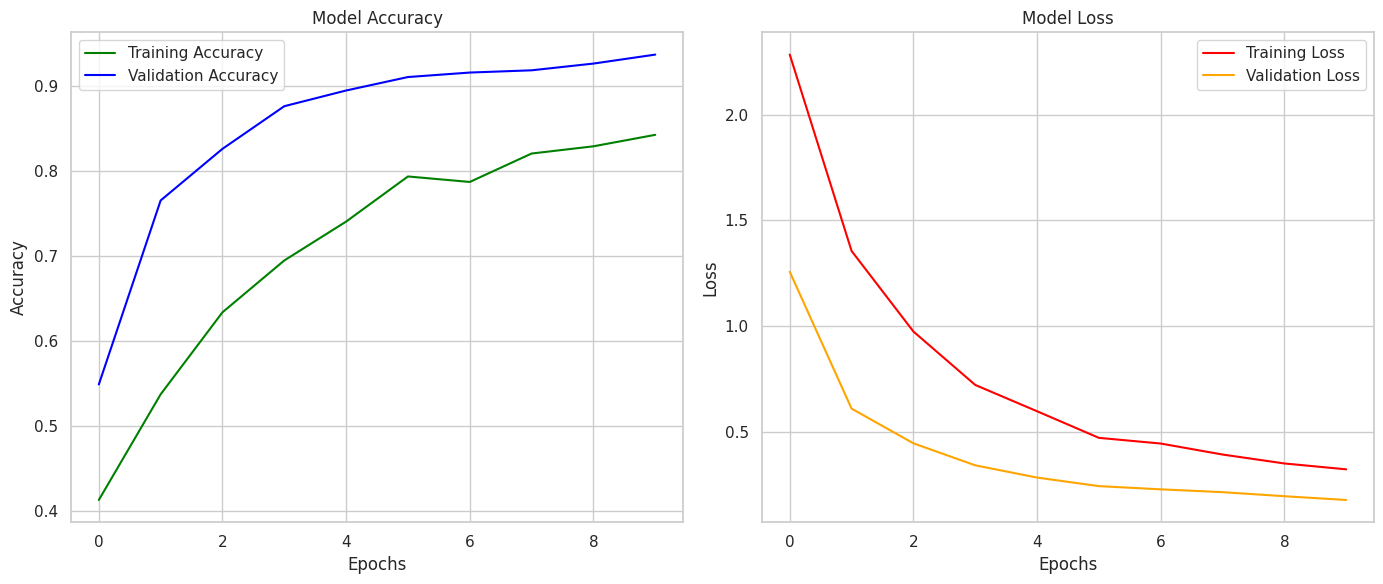

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

4/4 [==============================] - 39s 9s/step


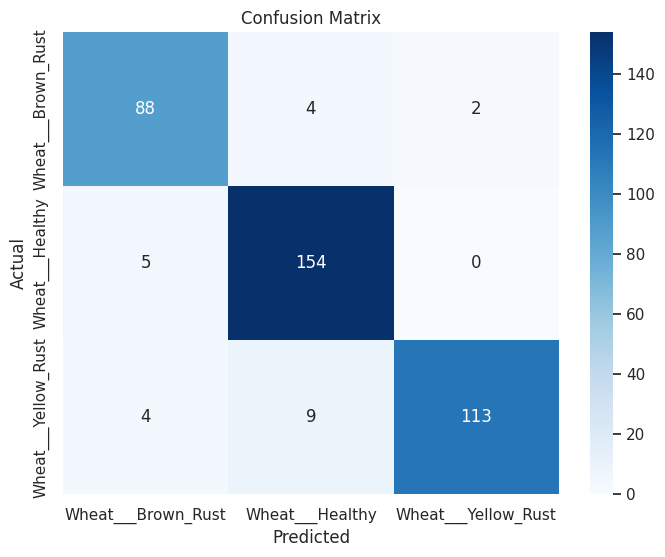

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in validation_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [18]:
# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)


Classification Report:

                     precision    recall  f1-score   support

 Wheat___Brown_Rust       0.91      0.94      0.92        94
    Wheat___Healthy       0.92      0.97      0.94       159
Wheat___Yellow_Rust       0.98      0.90      0.94       126

           accuracy                           0.94       379
          macro avg       0.94      0.93      0.93       379
       weighted avg       0.94      0.94      0.94       379

